In [2]:
import pandas as pd
df = pd.read_csv("surveyDataSience.csv",header = 1)
print("Numar resp: ", df.shape[0])

C:\Users\Deny\AppData\Local\Temp\ipykernel_23296\1152373676.py:2: DtypeWarning: Columns (0: Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Domo, 1: Which of the following business intelligence tools do you use on a regular basis? (Select all that apply) - Selected Choice - Thoughtspot ) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("surveyDataSience.csv",header = 1)


Numar resp:  25973


In [3]:
print("Nr atribute: ", df.shape[1])

Nr atribute:  369


In [4]:
print(df.dtypes)

Duration (in seconds)                                                                                                                                                                 int64
What is your age (# years)?                                                                                                                                                             str
What is your gender? - Selected Choice                                                                                                                                                  str
In which country do you currently reside?                                                                                                                                               str
What is the highest level of formal education that you have attained or plan to attain within the next 2 years?                                                                         str
                                                            

In [5]:
complete = df.dropna()
print("Respondenti cu date complete: ",complete.shape[0])

Respondenti cu date complete:  0


In [6]:
education_col = "What is the highest level of formal education that you have attained or plan to attain within the next 2 years?"

education_map = {
    "Bachelor’s degree": 3,
    "Master’s degree": 5,
    "Doctoral degree": 8,
}

df["YearsEducation"] = df[education_col].map(education_map)
medie = df["YearsEducation"].mean()
print("Durata medie estimata pt respondenti la studii", medie)

Durata medie estimata pt respondenti la studii 4.4994744678987475


In [7]:
medie_romania = df[df["In which country do you currently reside?"] == "Romania"]["YearsEducation"].mean()
print("Durata medie estimata pt respondenti romani la studii", medie_romania)

medie_romania_femei = df[(df["In which country do you currently reside?"] == "Romania") &
                         (df["What is your gender? - Selected Choice"] == "Woman")
]["YearsEducation"].mean()
print("Durata medie estimata pt respondenti romani femei la studii", medie_romania_femei)

Durata medie estimata pt respondenti romani la studii 5.08
Durata medie estimata pt respondenti romani femei la studii 5.428571428571429


In [8]:
femei_ro_complete = complete[
    (complete["In which country do you currently reside?"] == "Romania") &
    (complete["What is your gender? - Selected Choice"] == "Woman")
]

print("Femei RO cu date complete:", femei_ro_complete.shape[0])

Femei RO cu date complete: 0


In [9]:
python_col = "What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python"
cpp_col = "What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C++"

femei_ro = df[
    (df["In which country do you currently reside?"] == "Romania") &
    (df["What is your gender? - Selected Choice"] == "Woman")
]

python_femei = femei_ro[femei_ro[python_col].notna()]
cpp_femei = femei_ro[femei_ro[cpp_col].notna()]

print("Femei RO Python:", python_femei.shape[0])
print("Femei RO C++:", cpp_femei.shape[0])

Femei RO Python: 12
Femei RO C++: 4


In [10]:
age_col = "What is your age (# years)?"

print("Interval dominant Python:", python_femei[age_col].value_counts().idxmax())
print("Interval dominant C++:", cpp_femei[age_col].value_counts().idxmax())

Interval dominant Python: 35-39
Interval dominant C++: 18-21


In [11]:
for col in df.select_dtypes(include="object"):
    print(col)
    print("Valori unice:", df[col].nunique())

What is your age (# years)?
Valori unice: 11
What is your gender? - Selected Choice
Valori unice: 5
In which country do you currently reside?
Valori unice: 66
What is the highest level of formal education that you have attained or plan to attain within the next 2 years?
Valori unice: 7
Select the title most similar to your current role (or most recent title if retired): - Selected Choice
Valori unice: 15
For how many years have you been writing code and/or programming?
Valori unice: 7
What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python
Valori unice: 1
What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R
Valori unice: 1
What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - SQL
Valori unice: 1
What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C
Valori unice: 1
What programming langua

C:\Users\Deny\AppData\Local\Temp\ipykernel_23296\3967070783.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [12]:
import numpy as np

exp_col = "For how many years have you been writing code and/or programming?"

def mid_interval(interval):
    if pd.isna(interval):
        return np.nan
    interval = interval.replace("years","")
    if "+" in interval:
        return float(interval.replace("+", ""))
    if "<" in interval:
        return float(interval.replace("<",""))
    if "never" in interval:
        return 0.0
    parts = interval.split("-")
    return (float(parts[0]) + float(parts[1])) / 2

df["ExperienceYears"] = df[exp_col].apply(mid_interval)
print("Min:", df["ExperienceYears"].min())
print("Max:", df["ExperienceYears"].max())
print("Media:", df["ExperienceYears"].mean())
print("Std:", df["ExperienceYears"].std())
print("Mediana:", df["ExperienceYears"].median())

Min: 0.0
Max: 20.0
Media: 5.036210680321873
Std: 5.718301472746846
Mediana: 2.0


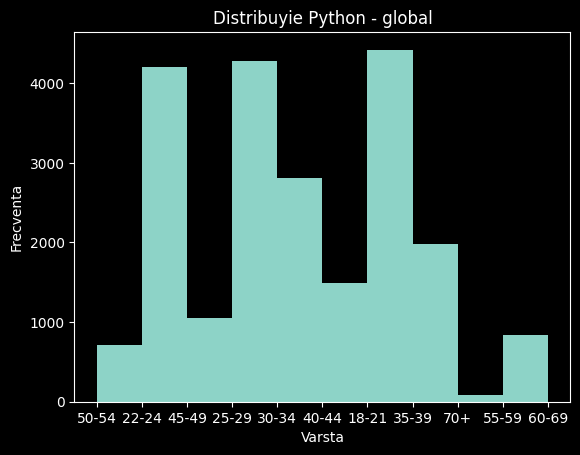

In [13]:
from matplotlib import pyplot as plt

python_all = df[df[python_col].notna()]

plt.hist(python_all[age_col])
plt.title("Distribuyie Python - global")
plt.xlabel("Varsta")
plt.ylabel("Frecventa")
plt.show()

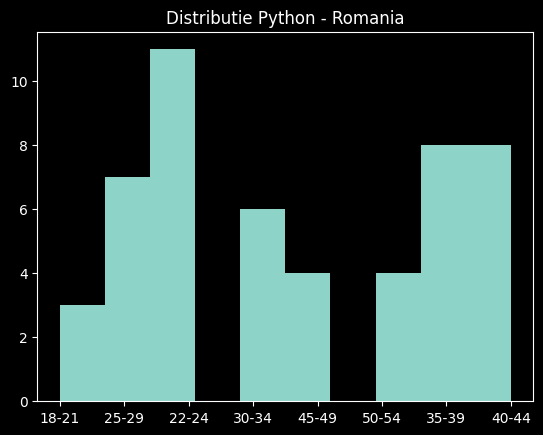

In [14]:
python_ro = df[
    (df["In which country do you currently reside?"] == "Romania") &
    (df[python_col].notna())
]

plt.hist(python_ro[age_col])
plt.title("Distributie Python - Romania")
plt.show()

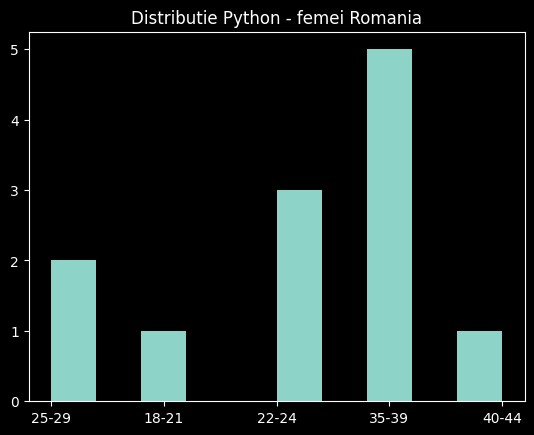

In [15]:
python_ro_f = df[
    (df["In which country do you currently reside?"] == "Romania") &
    (df["What is your gender? - Selected Choice"] == "Woman") &
    (df[python_col].notna())
]

plt.hist(python_ro_f[age_col])
plt.title("Distributie Python - femei Romania")
plt.show()

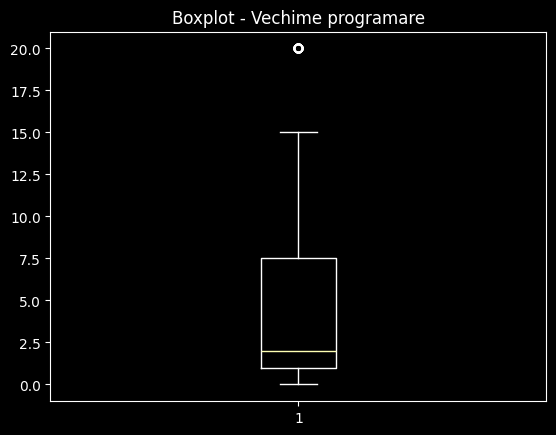

In [16]:
plt.boxplot(df["ExperienceYears"].dropna())
plt.title("Boxplot - Vechime programare")
plt.show()